
У меня задача классификации. Я взял датасэт, который представляет собой записи о пациентах с диабетом в 130 больницах США с 1999 по 2008. 
Моей задачей будет понять будет ли пациент повторно госпитализирован в какую-либо больницу.
Это необходимо для того, чтобы можно было изменить лечение и избежать повторной госпитализации.

В этой базе данных есть три разных варианта вывода:

- Никакой госпитализации;
- Повторная госпитализация менее чем через 30 дней (это плохой знак, возможно, лечение было неэффективным);
- Повторная госпитализация в течение более чем 30 дней (это не так хорошо, как предыдущая госпитализация, однако причиной может быть состояние пациента.



In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier
import time

1) Читаем данные

In [74]:
url = 'https://raw.githubusercontent.com/Andrew-Kop/ML_labs/main/diabetic_data.csv'
data = pd.read_csv(url, na_values=['?'], low_memory=False)
print(f"Размер датасета: {data.shape}")
print(f"Количество признаков: {data.shape[1]}")
print(f"Количество наблюдений: {data.shape[0]}")

Размер датасета: (101766, 50)
Количество признаков: 50
Количество наблюдений: 101766


Признаки имеют вид:

- `Encounter ID` — уникальный идентификатор госпитализации (можно удалить, не несёт аналитической нагрузки)
- `Patient number` — уникальный идентификатор пациента (также можно удалить, используется только для идентификации)
- `Race` — раса пациента — категориальный признак (Caucasian, Asian, African American, Hispanic, other)
- `Gender` — пол пациента — категориальный признак (male, female, unknown/invalid)
- `Age` — возраст пациента — категориальный признак, сгруппированный по 10-летним интервалам ([0,10), [10,20), …, [90,100))
- `Weight` — вес пациента в фунтах (numeric, пропусков 97%)
- `Admission type` — тип поступления (например, emergency, urgent, elective и др.) — категориальный признак
- `Discharge disposition` — исход госпитализации (discharged to home, expired и т.п.) — категориальный признак
- `Admission source` — источник направления (например, physician referral, emergency room) — категориальный признак
- `Time in hospital` — количество дней пребывания в больнице — числовой признак
- `Payer code` — страховой код (например, Blue Cross, Medicare, self-pay) — категориальный признак, 52% пропусков
- `Medical specialty` — специальность врача, принимавшего пациента (cardiology, internal medicine и др.) — категориальный признак, 53% пропусков
- `Number of lab procedures` — количество лабораторных тестов, выполненных за госпитализацию — числовой признак
- `Number of procedures` — количество процедур (кроме лабораторных) — числовой признак
- `Number of medications` — количество назначенных медикаментов — числовой признак
- `Number of outpatient visits` — число амбулаторных визитов пациента за предыдущий год — числовой признак
- `Number of emergency visits` — число обращений в отделение неотложной помощи за предыдущий год — числовой признак
- `Number of inpatient visits` — число госпитализаций за предыдущий год — числовой признак
- `Diagnosis 1`, `Diagnosis 2`, `Diagnosis 3` — основные и дополнительные диагнозы (кодированы по ICD9) — категориальные признаки
- `Number of diagnoses` — общее количество диагнозов, занесённых в систему — числовой признак
- `Glucose serum test result` — результат теста на глюкозу (">200", ">300", "normal", "none") — категориальный признак
- `A1c test result` — результат теста A1c (">8", ">7", "normal", "none") — категориальный признак
- `Change of medications` — наличие изменений в приёме медикаментов ("change" / "no change") — категориальный признак
- `Diabetes medications` — применялись ли диабетические препараты ("yes" / "no") — категориальный признак
- `24 features for medications` — информация по каждому из 24 препаратов (метформин, глимепирид и др.) — категориальные признаки ("up", "down", "steady", "no")
- `Readmitted` — целевой признак: был ли пациент повторно госпитализирован ("<30", ">30", "No")

Вот числовые признаки, которые можно взять из этого датасета:

- `time_in_hospital` — количество дней пребывания в больнице  
- `num_lab_procedures` — количество лабораторных тестов  
- `num_procedures` — количество процедур (кроме лабораторных)  
- `num_medications` — количество назначенных медикаментов  
- `number_outpatient` — число амбулаторных визитов за предыдущий год  
- `number_emergency` — число обращений в отделение неотложной помощи за предыдущий год  
- `number_inpatient` — число госпитализаций за предыдущий год  
- `number_diagnoses` — общее количество диагнозов  

Также технические признаки, мы их удалим:  
- `encounter_id`  
- `patient_nbr`  

Признаки с id (например, `admission_type_id`, `discharge_disposition_id`, `admission_source_id`) категориальные, хоть и имеют числовой тип, тоже рассматривать как числовые не будем.

2) Разбиваем на тестовую и обучающую выборки

Удаляем столбцы, которые приводят которые имеют слишком много пропусков('weight','max_glu_serum', 'A1Cresult'), слишком много уникальных значений ('diag_1', 'diag_2', 'diag_3'), а также признаки не несут нагрузки для аналитики

In [49]:
columns_to_drop = ['discharge_disposition_id', 'encounter_id',  'medical_specialty', 'patient_nbr', 'weight', 'payer_code', 'max_glu_serum', 'A1Cresult', 'diag_1', 'diag_2', 'diag_3'] 
data_helpful = data.drop(columns_to_drop, axis=1)
X = data_helpful.drop('readmitted', axis=1)
Y = data_helpful['readmitted']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.15, random_state=42)
print(f"Размер обучающих признаков: {X_train.shape}")
print(f"Размер тестовых признаков: {X_test.shape}")
print(f"Размер обучающей целевой переменной: {Y_train.shape}")
print(f"Размер тестовой целевой переменной: {Y_test.shape}")

Размер обучающих признаков: (86501, 38)
Размер тестовых признаков: (15265, 38)
Размер обучающей целевой переменной: (86501,)
Размер тестовой целевой переменной: (15265,)


3) Визуализация

In [50]:
num_cols = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

desc_num = data[num_cols].describe()
print("Основные статистики:\n", desc_num)

Основные статистики:
        time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
count     101766.000000       101766.000000   101766.000000    101766.000000   
mean           4.395987           43.095641        1.339730        16.021844   
std            2.985108           19.674362        1.705807         8.127566   
min            1.000000            1.000000        0.000000         1.000000   
25%            2.000000           31.000000        0.000000        10.000000   
50%            4.000000           44.000000        1.000000        15.000000   
75%            6.000000           57.000000        2.000000        20.000000   
max           14.000000          132.000000        6.000000        81.000000   

       number_outpatient  number_emergency  number_inpatient  number_diagnoses  
count      101766.000000     101766.000000     101766.000000     101766.000000  
mean            0.369357          0.197836          0.635566          7.422607  
std           

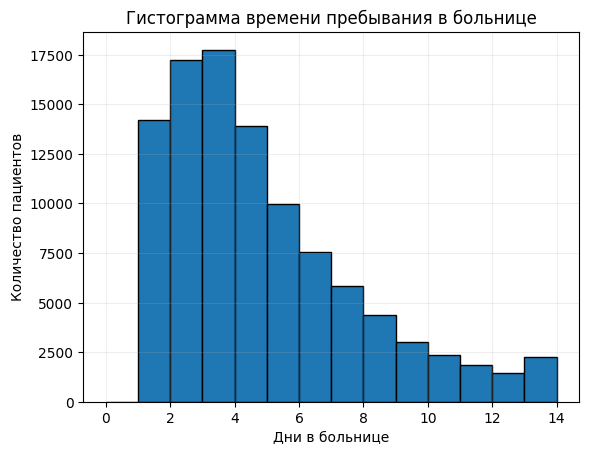

In [51]:
plt.hist(data['time_in_hospital'], bins=range(0, 15), edgecolor='black') 
plt.title('Гистограмма времени пребывания в больнице')
plt.xlabel('Дни в больнице')
plt.ylabel('Количество пациентов')
plt.grid(alpha=0.2) 
plt.show()

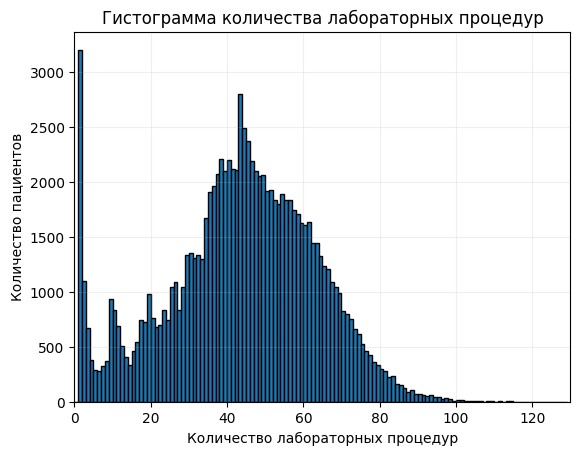

In [52]:
plt.hist(data['num_lab_procedures'], bins=range(0, 130), edgecolor='black') 
plt.title('Гистограмма количества лабораторных процедур')
plt.xlabel('Количество лабораторных процедур')
plt.ylabel('Количество пациентов')
plt.grid(alpha=0.2) 
plt.xlim(0,130)
plt.show()

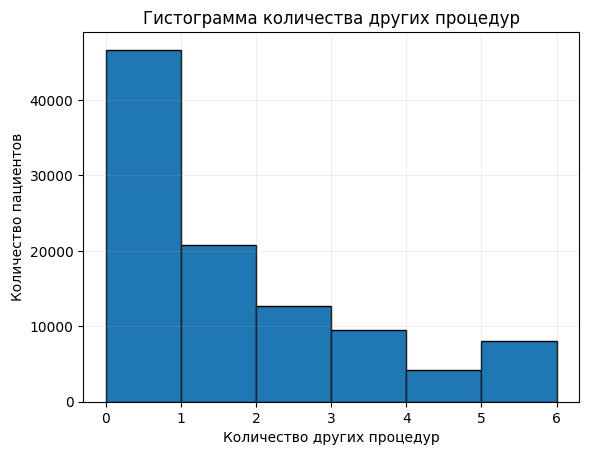

In [53]:
plt.hist(data['num_procedures'], bins=range(0,7), edgecolor='black') 
plt.title('Гистограмма количества других процедур')
plt.xlabel('Количество других процедур')
plt.ylabel('Количество пациентов')
plt.grid(alpha=0.2) 
plt.show()

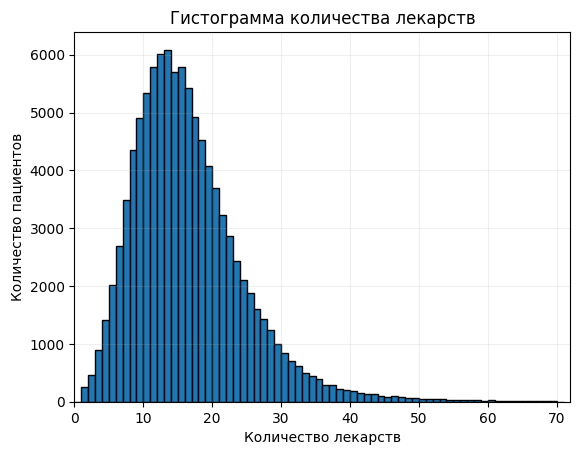

In [54]:
plt.hist(data['num_medications'], bins=range(0,72), edgecolor='black') 
plt.title('Гистограмма количества лекарств')
plt.xlabel('Количество лекарств')
plt.ylabel('Количество пациентов')
plt.grid(alpha=0.2) 
plt.xlim(0, 72)
plt.show()

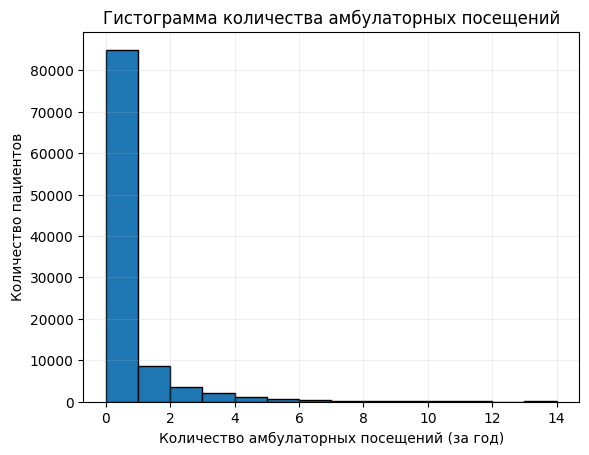

In [55]:
plt.hist(data['number_outpatient'], bins=range(0, 15), edgecolor='black') 
plt.title('Гистограмма количества амбулаторных посещений')
plt.xlabel('Количество амбулаторных посещений (за год)')
plt.ylabel('Количество пациентов')
#plt.xlim(0, 15)
plt.grid(alpha=0.2) 
plt.show()

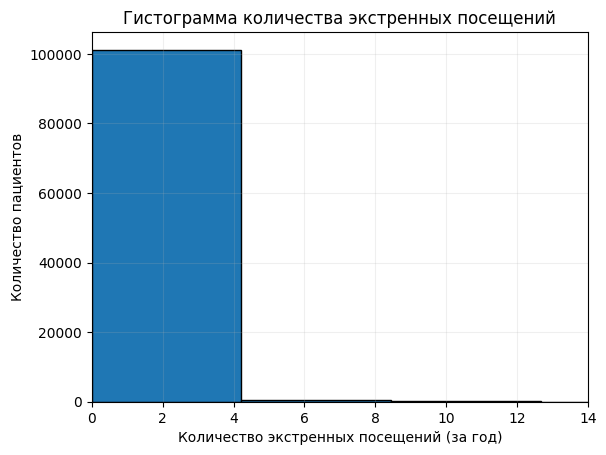

In [56]:
plt.hist(data['number_emergency'], bins='auto', edgecolor='black') 
plt.title('Гистограмма количества экстренных посещений')
plt.xlabel('Количество экстренных посещений (за год)')
plt.ylabel('Количество пациентов')
plt.xlim(0,14)
plt.grid(alpha=0.2) 
plt.show()

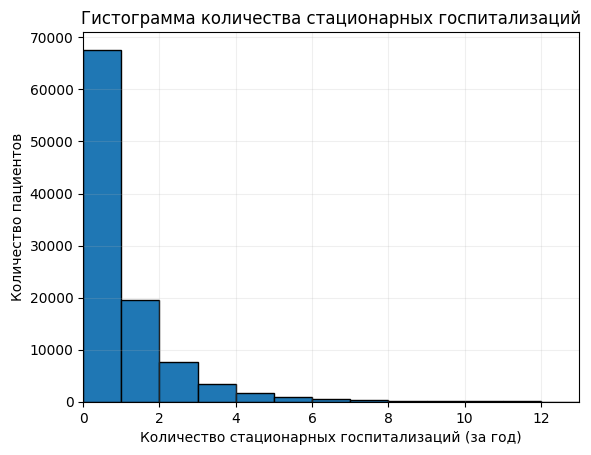

In [57]:
plt.hist(data['number_inpatient'], bins=range(0, 15), edgecolor='black') 
plt.title('Гистограмма количества стационарных госпитализаций')
plt.xlabel('Количество стационарных госпитализаций (за год)')
plt.ylabel('Количество пациентов')
plt.xlim(0,13)
plt.grid(alpha=0.2) 
plt.show()

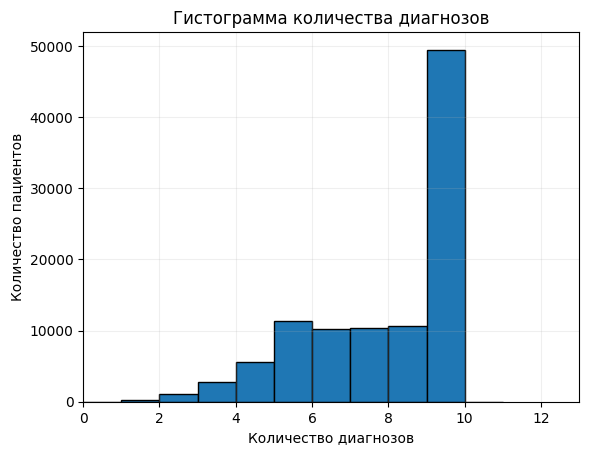

In [58]:
plt.hist(data['number_diagnoses'], bins=range(0,12), edgecolor='black') 
plt.title('Гистограмма количества диагнозов')
plt.xlabel('Количество диагнозов')
plt.ylabel('Количество пациентов')
plt.xlim(0,13)
plt.grid(alpha=0.2) 
plt.show()

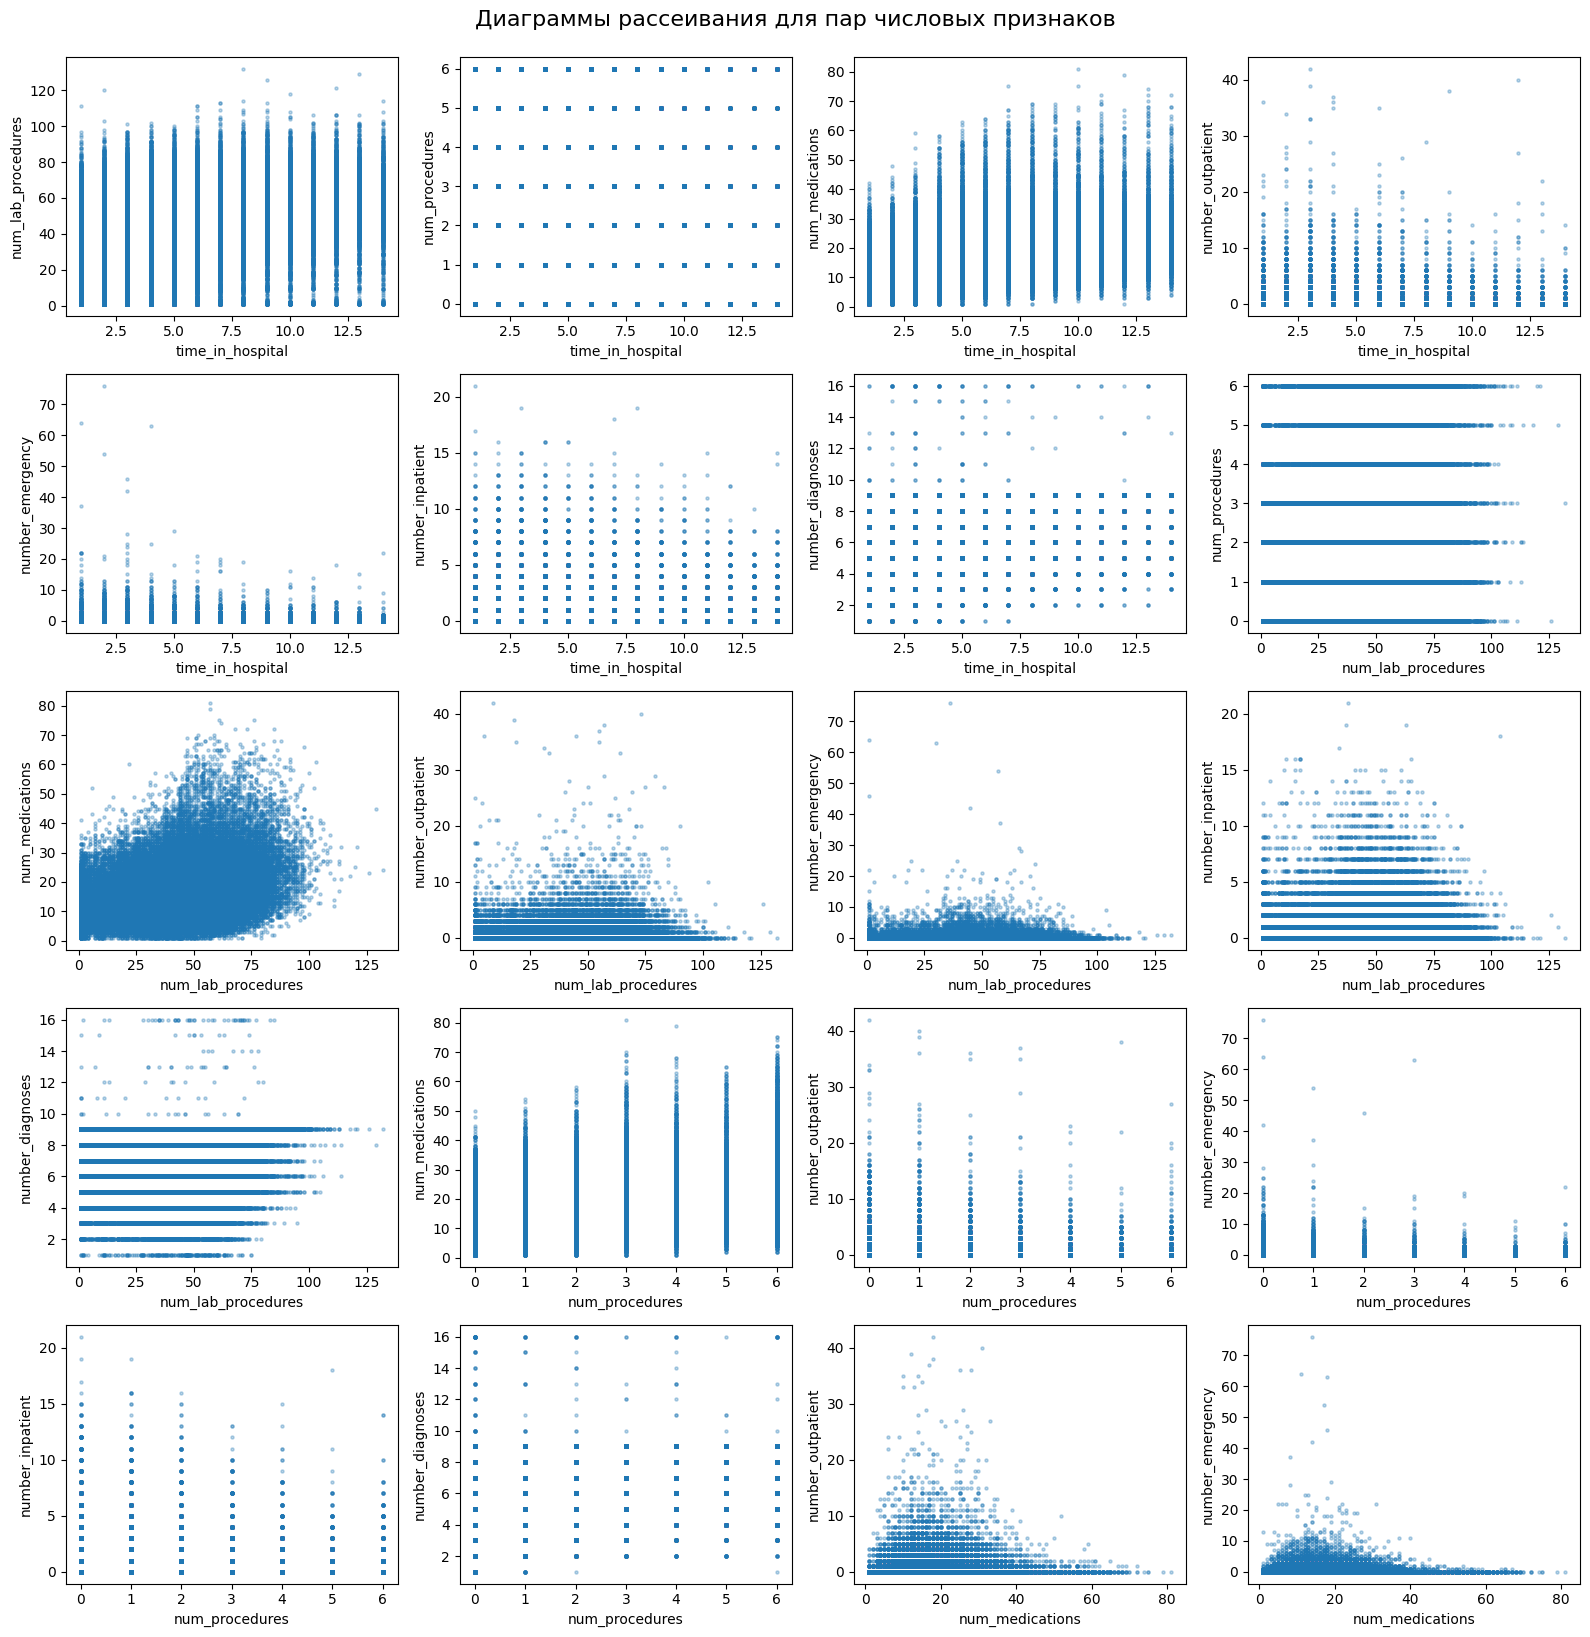

In [59]:
num_cols = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

import itertools

plt.figure(figsize=(16, 16))
plot_num = 1
for x_col, y_col in itertools.combinations(num_cols, 2):
    plt.subplot(5, 4, plot_num)
    plt.scatter(data[x_col], data[y_col], alpha=0.3, s=5)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plot_num += 1
    if plot_num > 20:
        break  

plt.suptitle('Диаграммы рассеивания для пар числовых признаков', y=1.02, fontsize=16)
plt.show()

Построим для числовых признаков диаграммы "ящик с усами" для того, чтобы проверить, что нет больших выбросов, которые могут повлиять на работу классификатора

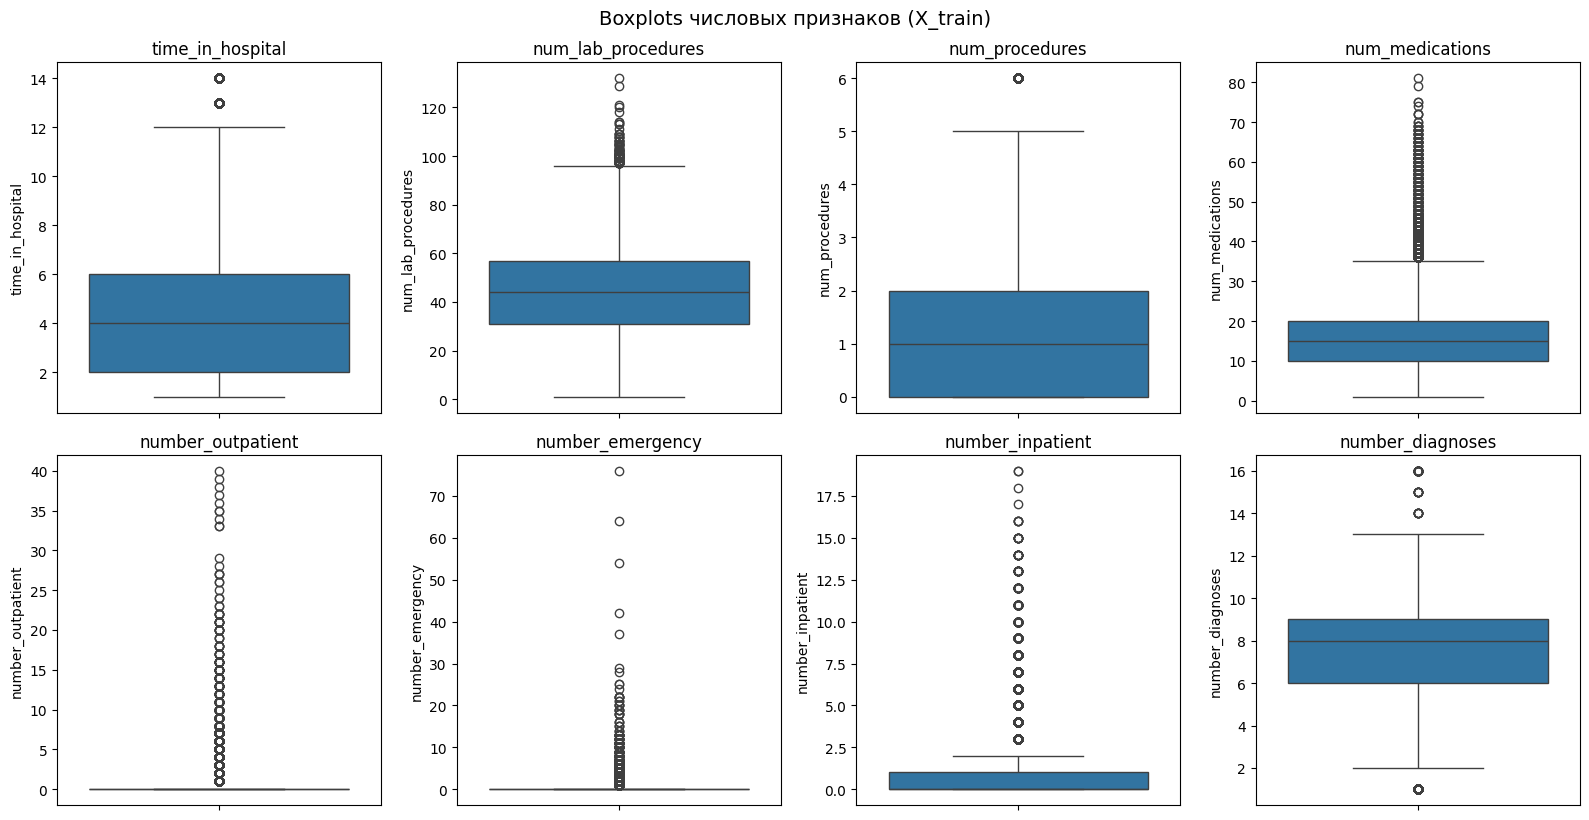

In [60]:
plt.figure(figsize=(16, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=X_train[col])
    plt.title(col)
    plt.tight_layout()

plt.suptitle('Boxplots числовых признаков (X_train)', y=1.02, fontsize=14)
plt.show()

На основании графиков можно сделать общий вывод:

Большинство числовых признаков имеют неравномерное распределение — у большинства пациентов значения небольшие, но есть и такие, у кого показатели сильно выше остальных. Это создаёт длинные хвосты и показывает наличие выбросов.

Особенно много выбросов видно в признаках num_lab_procedures, num_medications, number_emergency и number_outpatient. Это может быть связано с тем, что у некоторых пациентов были более сложные случаи или частые обращения в больницу.

В целом данные нуждаются в дополнительной обработке — стоит нормализовать числовые признаки и убрать или ограничить выбросы, чтобы модели обучались точнее.

Построим матрицу корелляции, чтобы увидеть зависимости между числовыми признаками

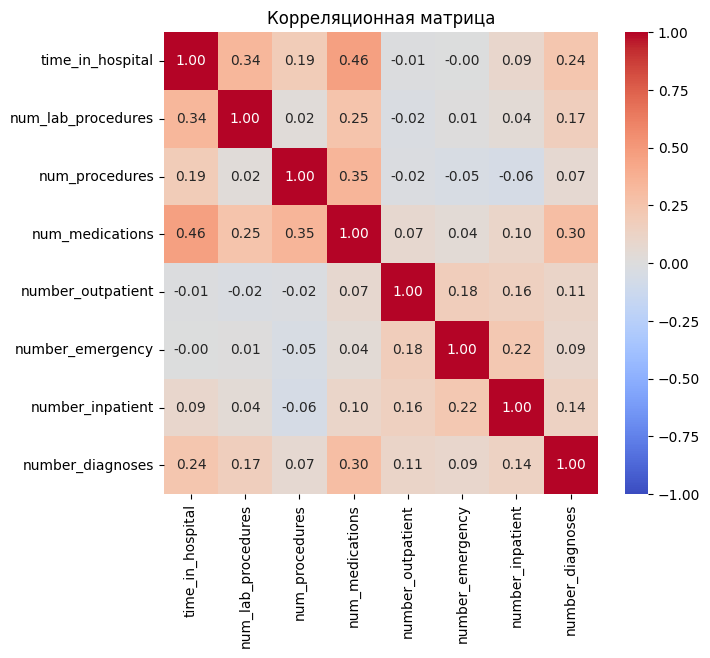

In [61]:
corr_ff = X_train[num_cols].corr(method='spearman')
plt.figure(figsize=(7, 6))
sns.heatmap(corr_ff, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Корреляционная матрица')
plt.show()

Длительность лечения и лекарства: Чем дольше пациент в больнице (time_in_hospital), тем больше он получает медикаментов (num_medications) (связь 0.46).

Лекарства и процедуры: Больше медикаментов также связано с большим количеством общих процедур (num_procedures) (связь 0.35).

Использование услуг: Пациенты с частыми экстренными обращениями (number_emergency) также чаще имеют стационарные госпитализации (number_inpatient) (связь 0.22).

Лабораторные тесты и время: Время в больнице также умеренно связано с количеством лабораторных тестов (num_lab_procedures) (связь 0.34).

4) Обрабатываем пропущенные значения

In [62]:
missing = data.isnull().sum()
percent = (missing / len(data)) * 100
missing_df = pd.DataFrame({'missing': missing, 'percent': percent.round(2)})
print("Пропущенные значения в исходных данных:")
print(missing_df[missing_df['missing'] > 0])

categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    if col in X_train.columns:
        mode_value = X_train[col].mode()[0] if not X_train[col].mode().empty else 'Unknown'
        X_train[col] = X_train[col].fillna(mode_value)
        X_test[col] = X_test[col].fillna(mode_value)

numerical_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
for col in numerical_cols:
    if col in X_train.columns and X_train[col].isna().any():
        median_value = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_value)
        X_test[col] = X_test[col].fillna(median_value)

print(f"\nПосле заполнения пропусков:")
print(f"X_train NaN: {X_train.isnull().sum().sum()}")
print(f"X_test NaN: {X_test.isnull().sum().sum()}")


Пропущенные значения в исходных данных:
                   missing  percent
race                  2273     2.23
weight               98569    96.86
payer_code           40256    39.56
medical_specialty    49949    49.08
diag_1                  21     0.02
diag_2                 358     0.35
diag_3                1423     1.40
max_glu_serum        96420    94.75
A1Cresult            84748    83.28

После заполнения пропусков:
X_train NaN: 0
X_test NaN: 0


Все признаки стали заполнены 

5)Обработка категориальных данных и стандартазицация данных

In [63]:
label_encoder = LabelEncoder()
binary_features = ['gender', 'change', 'diabetesMed']

for feature in binary_features:
    if feature in X_train.columns:
        X_train[feature] = label_encoder.fit_transform(X_train[feature])
        X_test[feature] = label_encoder.transform(X_test[feature])

age_mapping = {
    '[0-10)': 0, '[10-20)': 1, '[20-30)': 2, '[30-40)': 3, '[40-50)': 4,
    '[50-60)': 5, '[60-70)': 6, '[70-80)': 7, '[80-90)': 8, '[90-100)': 9
}

if 'age' in X_train.columns:
    unknown_ages = set(X_train['age'].unique()) - set(age_mapping.keys())
    if unknown_ages:
        print(f"Обнаружены неизвестные значения возраста: {unknown_ages}")
        for age_val in unknown_ages:
            age_mapping[age_val] = 5
    
    X_train['age'] = X_train['age'].map(age_mapping)
    X_test['age'] = X_test['age'].map(age_mapping)
    X_train['age'] = X_train['age'].fillna(5)
    X_test['age'] = X_test['age'].fillna(5)

medication_features = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
                      'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
                      'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
                      'miglitol', 'troglitazone', 'tolazamide', 'examide',
                      'citoglipton', 'insulin', 'glyburide-metformin',
                      'glipizide-metformin', 'glimepiride-pioglitazone',
                      'metformin-rosiglitazone', 'metformin-pioglitazone']

medication_mapping = {'No': 0, 'Steady': 1, 'Down': 2, 'Up': 3}

for med_feature in medication_features:
    if med_feature in X_train.columns:
        unique_values = set(X_train[med_feature].unique())
        unknown_meds = unique_values - set(medication_mapping.keys())
        if unknown_meds:
            print(f"Неизвестные значения в {med_feature}: {unknown_meds}")
            for med_val in unknown_meds:
                medication_mapping[med_val] = 0
        
        X_train[med_feature] = X_train[med_feature].map(medication_mapping)
        X_test[med_feature] = X_test[med_feature].map(medication_mapping)
        X_train[med_feature] = X_train[med_feature].fillna(0)
        X_test[med_feature] = X_test[med_feature].fillna(0)

categorical_features_for_ohe = ['race', 'admission_type_id',  
                               'admission_source_id']

existing_categorical = [col for col in categorical_features_for_ohe if col in X_train.columns]

if existing_categorical:
    X_train = pd.get_dummies(X_train, columns=existing_categorical, drop_first=True)
    X_test = pd.get_dummies(X_test, columns=existing_categorical, drop_first=True)
    X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print(f"После обработки категориальных признаков:")
print(f"Количество признаков: {X_train.shape[1]}")

После обработки категориальных признаков:
Количество признаков: 62


6)Нормализация данных

In [ ]:
num_cols = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
    'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses'
]

existing_num_cols = [col for col in num_cols if col in X_train.columns]

if existing_num_cols:
    scaler = StandardScaler()
    X_train[existing_num_cols] = scaler.fit_transform(X_train[existing_num_cols])
    X_test[existing_num_cols] = scaler.transform(X_test[existing_num_cols])
    print(f"Нормализованы признаки: {existing_num_cols}")

print(f"\nУникальные значения в Y_train до маппинга: {sorted(Y_train.unique())}")
print(f"Уникальные значения в Y_test до маппинга: {sorted(Y_test.unique())}")

Y_train = Y_train.map({'NO': 0, 'No': 0, '>30': 1, '<30': 2})
Y_test = Y_test.map({'NO': 0, 'No': 0, '>30': 1, '<30': 2})

print(f"\nУникальные значения в Y_train после маппинга: {sorted(Y_train.unique())}")
print(f"Уникальные значения в Y_test после маппинга: {sorted(Y_test.unique())}")
print(f"Распределение Y_train после маппинга:")
print(Y_train.value_counts().sort_index())
print(f"Распределение Y_test после маппинга:")
print(Y_test.value_counts().sort_index())

if Y_train.isnull().sum() > 0 or Y_test.isnull().sum() > 0:
    most_frequent_class = Y_train.mode()[0] if not Y_train.mode().empty else 0
    Y_train = Y_train.fillna(most_frequent_class)
    Y_test = Y_test.fillna(most_frequent_class)

print(f"\nФинальные размеры данных:")
print(f"X_train: {X_train.shape}, Y_train: {Y_train.shape}")
print(f"X_test: {X_test.shape}, Y_test: {Y_test.shape}")

Нормализованы признаки: ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
Нормализация необходима для KNN, так как алгоритм основан на расстояниях

Уникальные значения в Y_train до маппинга: ['<30', '>30', 'NO']
Уникальные значения в Y_test до маппинга: ['<30', '>30', 'NO']

Уникальные значения в Y_train после маппинга: [0, 1, 2]
Уникальные значения в Y_test после маппинга: [0, 1, 2]
Распределение Y_train после маппинга:
readmitted
0    46687
1    30189
2     9625
Name: count, dtype: int64
Распределение Y_test после маппинга:
readmitted
0    8177
1    5356
2    1732
Name: count, dtype: int64

Финальные размеры данных:
X_train: (86501, 62), Y_train: (86501,)
X_test: (15265, 62), Y_test: (15265,)


Нормализация нужна так как Knn построен на расстояниях и по ящикам с усами мы могли наблюдать выбросы

7)Запуск классификатора

k=2: train_acc=0.7340, test_acc=0.5306
k=3: train_acc=0.7177, test_acc=0.5106
k=4: train_acc=0.6791, test_acc=0.5282
k=5: train_acc=0.6647, test_acc=0.5298
k=6: train_acc=0.6494, test_acc=0.5372
k=7: train_acc=0.6447, test_acc=0.5364
k=8: train_acc=0.6334, test_acc=0.5418
k=9: train_acc=0.6295, test_acc=0.5450
k=10: train_acc=0.6242, test_acc=0.5471
k=11: train_acc=0.6204, test_acc=0.5477
k=12: train_acc=0.6168, test_acc=0.5513
k=13: train_acc=0.6142, test_acc=0.5501
k=14: train_acc=0.6108, test_acc=0.5509
k=15: train_acc=0.6090, test_acc=0.5539
k=16: train_acc=0.6075, test_acc=0.5538
k=17: train_acc=0.6049, test_acc=0.5546
k=18: train_acc=0.6032, test_acc=0.5568
k=19: train_acc=0.6018, test_acc=0.5592
k=20: train_acc=0.6001, test_acc=0.5598
k=21: train_acc=0.5988, test_acc=0.5581
k=22: train_acc=0.5985, test_acc=0.5603
k=23: train_acc=0.5968, test_acc=0.5594
k=24: train_acc=0.5975, test_acc=0.5589
k=25: train_acc=0.5968, test_acc=0.5603
k=26: train_acc=0.5959, test_acc=0.5625
k=27: tr

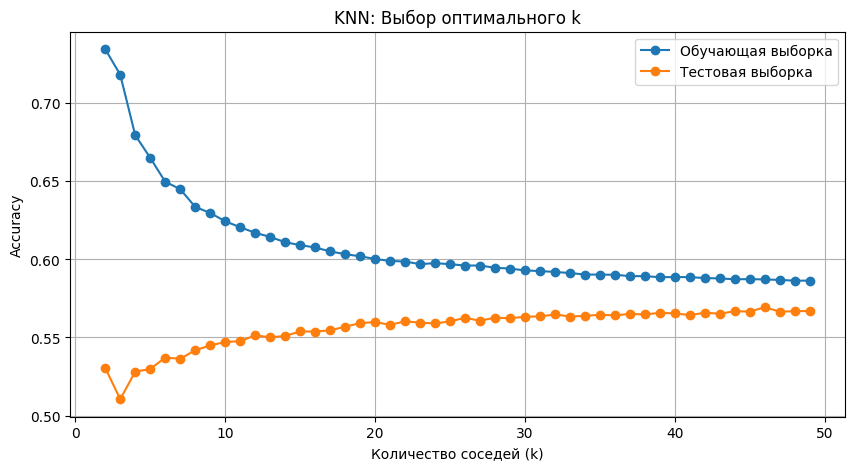

Оптимальное количество соседей: 46


In [67]:
start_time = time.time()

k_values = range(2,50) 
train_scores = []
test_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1) 
    knn.fit(X_train, Y_train)
    
    train_pred = knn.predict(X_train)
    test_pred = knn.predict(X_test)
    
    train_acc = accuracy_score(Y_train, train_pred)
    test_acc = accuracy_score(Y_test, test_pred)
    
    train_scores.append(train_acc)
    test_scores.append(test_acc)
    print(f"k={k}: train_acc={train_acc:.4f}, test_acc={test_acc:.4f}")

knn_time = time.time() - start_time
print(f"KNN занял {knn_time:.2f} секунд")

plt.figure(figsize=(10, 5))
plt.plot(k_values, train_scores, 'o-', label='Обучающая выборка')
plt.plot(k_values, test_scores, 'o-', label='Тестовая выборка')
plt.xlabel('Количество соседей (k)')
plt.ylabel('Accuracy')
plt.title('KNN: Выбор оптимального k')
plt.legend()
plt.grid(True)
plt.show()

optimal_k = k_values[np.argmax(test_scores)]
print(f"Оптимальное количество соседей: {optimal_k}")


Почему я выбрал Knn:
Простота: Легко понять и реализовать, минимальные настройки

Локальные зависимости: В медицинских данных похожие пациенты часто имеют схожие исходы

Интерпретируемость: Можно показать "похожих соседей" как обоснование предсказания

8)Вычисление ошибок и матриц рассогласования

Accuracy на обучающей выборке: 0.5871
Accuracy на тестовой выборке: 0.5693


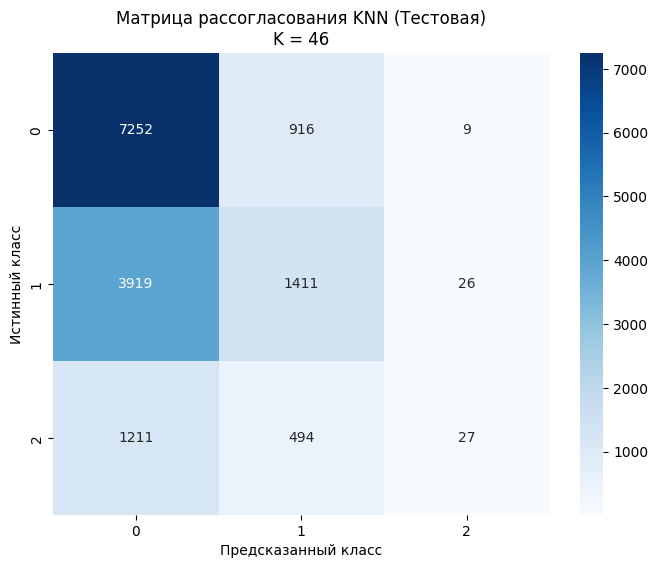


Интерпретация матрицы рассогласования:
Диагональные элементы - правильные предсказания
Внедиагональные элементы - ошибки классификации
Общая точность: 0.5693


In [68]:
final_knn = KNeighborsClassifier(n_neighbors=optimal_k, n_jobs=-1)
final_knn.fit(X_train, Y_train)

y_train_pred = final_knn.predict(X_train)
y_test_pred = final_knn.predict(X_test)

print(f"Accuracy на обучающей выборке: {accuracy_score(Y_train, y_train_pred):.4f}")
print(f"Accuracy на тестовой выборке: {accuracy_score(Y_test, y_test_pred):.4f}")

plt.figure(figsize=(8, 6))
cm_test = confusion_matrix(Y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues')
plt.title(f'Матрица рассогласования KNN (Тестовая)\nK = {optimal_k}')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

print("\nИнтерпретация матрицы рассогласования:")
print("Диагональные элементы - правильные предсказания")
print("Внедиагональные элементы - ошибки классификации")
print(f"Общая точность: {accuracy_score(Y_test, y_test_pred):.4f}")

9)Сравнение с другими классификаторами

In [73]:
# KNN
start_time = time.time()
knn = KNeighborsClassifier(n_neighbors=optimal_k, n_jobs=-1)  
knn.fit(X_train, Y_train)
y_test_knn = knn.predict(X_test)
knn_time = time.time() - start_time

# Логистическая регрессия
start_time = time.time()
log_reg = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
log_reg.fit(X_train, Y_train)
y_test_log = log_reg.predict(X_test)
logreg_time = time.time() - start_time

# Решающее дерево
start_time = time.time()
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, Y_train)
y_test_tree = tree.predict(X_test)
tree_time = time.time() - start_time

# Сравнение
comparison = pd.DataFrame({
    'Method': ['KNN', 'Logistic Regression', 'Decision Tree'],
    'Test Accuracy': [
        accuracy_score(Y_test, y_test_knn),
        accuracy_score(Y_test, y_test_log),
        accuracy_score(Y_test, y_test_tree)
    ],
    'Time (sec)': [knn_time, logreg_time, tree_time]
})

print(comparison)

                Method  Test Accuracy  Time (sec)
0                  KNN       0.569276    2.335634
1  Logistic Regression       0.570324    8.733830
2        Decision Tree       0.461644    0.784450


10)Анализ несбалансированности классов

In [70]:
print("Распределение классов в обучающей выборке:")
print(Y_train.value_counts().sort_index())
print(f"\nПроцентное распределение:")
print(Y_train.value_counts(normalize=True).sort_index() * 100)

print("\nРаспределение классов в тестовой выборке:")
print(Y_test.value_counts().sort_index())
print(f"\nПроцентное распределение:")
print(Y_test.value_counts(normalize=True).sort_index() * 100)

print("\nДетальный отчет KNN (Тестовая выборка):")
print(classification_report(Y_test, y_test_pred, 
                          target_names=['No readmission', 'Readmission >30', 'Readmission <30']))

Распределение классов в обучающей выборке:
readmitted
0    46687
1    30189
2     9625
Name: count, dtype: int64

Процентное распределение:
readmitted
0    53.972786
1    34.900175
2    11.127039
Name: proportion, dtype: float64

Распределение классов в тестовой выборке:
readmitted
0    8177
1    5356
2    1732
Name: count, dtype: int64

Процентное распределение:
readmitted
0    53.566983
1    35.086800
2    11.346217
Name: proportion, dtype: float64

Детальный отчет KNN (Тестовая выборка):
                 precision    recall  f1-score   support

 No readmission       0.59      0.89      0.71      8177
Readmission >30       0.50      0.26      0.35      5356
Readmission <30       0.44      0.02      0.03      1732

       accuracy                           0.57     15265
      macro avg       0.51      0.39      0.36     15265
   weighted avg       0.54      0.57      0.50     15265



Общие выводы:
Мы попробовали предсказать, когда диабетики снова попадут в больницу, используя три разных метода.

Логистическая Регрессия и KNN (ближайшие соседи) сработали лучше всего, угадав правильно примерно 57% случаев.

Дерево Решений показало самый слабый результат — всего 46%.

Главный вывод: Точность 57% — это достаточно низко. Это означает, что модели с трудом предсказывают значения. Как видно из матрицы рассогласования это следует из того, что сложно определить будет ли госпитализирован после месяца от последнего приёма или не будет госпитазирован вовсе
